# Boiler Plate

In [1]:
library(tidyverse)
library(knitr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# theme to add to all plots
# theme_set(theme_bw(base_size = 20))
# library(tidyverse)
theme_set(theme_classic(base_size = 25))

In [3]:
packageurl<-"https://cran.r-project.org/src/contrib/Archive/nloptr/nloptr_1.2.1.tar.gz"

install.packages(packageurl, repos=NULL, type="source")
install.packages("lme4")
library(lme4)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘minqa’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




In [4]:
data <- read_csv('Source-Goal_eyetracking_behavior_data.csv')

Rows: 3696 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Condition, Target_EventID, Choice, Source_mentioned, Goal_mentioned
dbl (2): Participant, Trial_Number

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Language

In [5]:
description_data <- data %>%
filter(!grepl("Non",Condition, fixed = TRUE) ) %>%
select(Participant, Condition, Trial_Number, Target_EventID, Choice, Source_mentioned, Goal_mentioned) %>%
# exclude participants whose runs were deemed usable based on experimenter observation (e.g., using the phone)
filter (!Participant %in% c(80,85,123)) %>%
# look at target event only
filter(!Target_EventID %in% c("Car", "Helicopter", "Girl", "Oldlady", "Ghost", "Cow", "Man", "Police", "Cat", "Farmer", "Boy", "Dog") ) %>%
# exclude trials where participants did not provide a description
filter(!(Source_mentioned == "n/a"| Goal_mentioned == "n/a")) %>%
mutate(Source_mentioned.numeral = ifelse(Source_mentioned == '1', 1, 0)) %>%
mutate(Goal_mentioned.numeral = ifelse(Goal_mentioned == '1', 1, 0))

In [6]:
summary(description_data)

  Participant      Condition          Trial_Number   Target_EventID    
 Min.   :  9.00   Length:1021        Min.   : 1.00   Length:1021       
 1st Qu.: 32.00   Class :character   1st Qu.: 7.00   Class :character  
 Median : 95.00   Mode  :character   Median :15.00   Mode  :character  
 Mean   : 83.35                      Mean   :14.54                     
 3rd Qu.:116.00                      3rd Qu.:22.00                     
 Max.   :132.00                      Max.   :28.00                     
    Choice          Source_mentioned   Goal_mentioned    
 Length:1021        Length:1021        Length:1021       
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                                         
 Source_mentioned.numeral Goal_mentioned.numeral
 Min.   :0.0000           Min.   :0.0000 

In [ ]:
summary(description_data)

  Participant      Condition          Trial_Number  Target_EventID    
 Min.   :  9.00   Length:1024        Min.   : 1.0   Length:1024       
 1st Qu.: 53.00   Class :character   1st Qu.: 7.0   Class :character  
 Median : 94.50   Mode  :character   Median :14.5   Mode  :character  
 Mean   : 83.33                      Mean   :14.5                     
 3rd Qu.:115.25                      3rd Qu.:22.0                     
 Max.   :132.00                      Max.   :28.0                     
    Choice          Source_mentioned   Goal_mentioned        Answer         
 Length:1024        Length:1024        Length:1024        Length:1024       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                         

In [7]:
participant_mention <- description_data %>% group_by(Participant) %>%
summarize(n=n(), Source_mention_rate = sum(Source_mentioned.numeral)/n, Goal_mention_rate = sum(Goal_mentioned.numeral)/n) %>% arrange(Source_mention_rate, Goal_mention_rate)
participant_mention %>% kable



| Participant|  n| Source_mention_rate| Goal_mention_rate|
|-----------:|--:|-------------------:|-----------------:|
|          88| 15|           0.0666667|         0.8000000|
|         109| 16|           0.1250000|         0.8125000|
|          29| 16|           0.2500000|         1.0000000|
|         115| 16|           0.3125000|         0.8125000|
|         104| 16|           0.5000000|         1.0000000|
|          17| 16|           0.5625000|         1.0000000|
|         122| 16|           0.6250000|         1.0000000|
|          19| 16|           0.7500000|         0.9375000|
|         100| 16|           0.7500000|         0.9375000|
|         132| 16|           0.7500000|         1.0000000|
|           9| 16|           0.8125000|         1.0000000|
|          16| 16|           0.8125000|         1.0000000|
|          86| 16|           0.8750000|         0.8125000|
|         111| 16|           0.8750000|         0.8750000|
|          31| 16|           0.8750000|         1.0000

In [8]:
participant_mention %>%
summarize(mean_Source=mean(Source_mention_rate), mean_Goal=mean(Goal_mention_rate), sd_Source= sd(Source_mention_rate), sd_Goal=mean(Goal_mention_rate)) %>% kable



| mean_Source| mean_Goal| sd_Source|   sd_Goal|
|-----------:|---------:|---------:|---------:|
|   0.8749256| 0.9772042| 0.2071403| 0.9772042|

In [9]:
description_data_longer <- description_data %>% pivot_longer(cols = Source_mentioned.numeral: Goal_mentioned.numeral, names_to = "Role", values_to = "Mentioned") %>%
mutate(Role.fct = factor(Role, levels = c("Source_mentioned.numeral", "Goal_mentioned.numeral")) )
description_data_longer %>% kable



| Participant|Condition                       | Trial_Number|Target_EventID |Choice    |Source_mentioned |Goal_mentioned |Role                     | Mentioned|Role.fct                 |
|-----------:|:-------------------------------|------------:|:--------------|:---------|:----------------|:--------------|:------------------------|---------:|:------------------------|
|           9|Linguistic_List1a_Source_Change |            1|Beetle         |same      |0                |1              |Source_mentioned.numeral |         0|Source_mentioned.numeral |
|           9|Linguistic_List1a_Source_Change |            1|Beetle         |same      |0                |1              |Goal_mentioned.numeral   |         1|Goal_mentioned.numeral   |
|           9|Linguistic_List1a_Source_Change |            3|Snake          |same      |1                |1              |Source_mentioned.numeral |         1|Source_mentioned.numeral |
|           9|Linguistic_List1a_Source_Change |            3|Snake  

In [10]:
contrasts(description_data_longer$Role.fct) = contr.sum(2)
m<- glmer(Mentioned ~ Role.fct + (1+Role.fct|Participant) + (1+Role.fct|Target_EventID ) , family = "binomial", data = description_data_longer)
summary(m)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Mentioned ~ Role.fct + (1 + Role.fct | Participant) + (1 + Role.fct |  
    Target_EventID)
   Data: description_data_longer

      AIC       BIC    logLik -2*log(L)  df.resid 
    771.0     816.0    -377.5     755.0      2034 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-10.1346   0.0599   0.1152   0.2004   5.4575 

Random effects:
 Groups         Name        Variance Std.Dev. Corr
 Participant    (Intercept) 2.6813   1.6375       
                Role.fct1   0.4727   0.6875   0.22
 Target_EventID (Intercept) 0.7315   0.8553       
                Role.fct1   0.1106   0.3326   0.09
Number of obs: 2042, groups:  Participant, 64; Target_EventID, 16

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   4.2493     0.4656   9.127  < 2e-16 ***
Role.fct1    -1.0479     0.3788  -2.767  0.00566 ** 
---
Signif. cod

# Memory data

In [5]:
#load non-linguistic conditions
memory_data_nl <- data %>% filter(grepl("Non",Condition, fixed = TRUE) ) %>%
# exclude participants whose runs were deemed usable based on experimenter observation (e.g., using the phone)
filter (!Participant %in% c(61,80,85,123)) %>%
select(Participant, Condition, Trial_Number, Target_EventID, Choice) %>%
filter(!Target_EventID %in% c("Car", "Helicopter", "Girl", "Oldlady", "Ghost", "Cow", "Man", "Police", "Cat", "Farmer", "Boy", "Dog") ) %>%
mutate(Answer= "different")%>%
mutate(Correct = ifelse(Choice == Answer, 1,0)) %>%
mutate(Encoding = "NonLinguistic")

In [6]:
#load linguistic conditions
memory_data_l <- data %>% filter(!grepl("Non",Condition, fixed = TRUE) ) %>%
# exclude participants whose runs were deemed usable based on experimenter observation (e.g., using the phone)
filter (!Participant %in% c(61,80,85,123)) %>%
select(Participant, Condition, Trial_Number, Target_EventID, Choice) %>%
filter(!Target_EventID %in% c("Car", "Helicopter", "Girl", "Oldlady", "Ghost", "Cow", "Man", "Police", "Cat", "Farmer", "Boy", "Dog") ) %>%
mutate(Answer= "different")%>%
mutate(Correct = ifelse(Choice == Answer, 1,0)) %>%
mutate(Encoding = "Linguistic")

In [7]:
memory_data <- rbind(memory_data_nl, memory_data_l)

In [8]:
memory_data <- memory_data %>%
  mutate(
    Change_type = case_when(
      str_detect(Condition, "Source") ~ "Source",
      str_detect(Condition, "Goal") ~ "Goal",
      TRUE ~ NA_character_
    )
  )

In [9]:
memory_data %>% head()

Participant,Condition,Trial_Number,Target_EventID,Choice,Answer,Correct,Encoding,Change_type
<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,NonLinguistic_List1a_Source_Change,1,Beetle,same,different,0,NonLinguistic,Source
1,NonLinguistic_List1a_Source_Change,3,Snake,different,different,1,NonLinguistic,Source
1,NonLinguistic_List1a_Source_Change,5,Fairy,different,different,1,NonLinguistic,Source
1,NonLinguistic_List1a_Source_Change,7,Horse,different,different,1,NonLinguistic,Source
1,NonLinguistic_List1a_Source_Change,9,Hamster,different,different,1,NonLinguistic,Source
1,NonLinguistic_List1a_Source_Change,11,Butterfly,different,different,1,NonLinguistic,Source


In [10]:
memory_data %>% group_by(Condition) %>% summarize(n = n())%>% kable
#one additional kid in "NonLinguistic_List2a_Goal_Change" was 61, drop him?



|Condition                          |   n|
|:----------------------------------|---:|
|Linguistic_List1a_Goal_Change      | 128|
|Linguistic_List1a_Source_Change    | 128|
|Linguistic_List1b_Goal_Change      | 128|
|Linguistic_List1b_Source_Change    | 128|
|Linguistic_List2a_Goal_Change      | 128|
|Linguistic_List2a_Source_Change    | 128|
|Linguistic_List2b_Goal_Change      | 128|
|Linguistic_List2b_Source_Change    | 128|
|NonLinguistic_List1a_Goal_Change   | 128|
|NonLinguistic_List1a_Source_Change | 128|
|NonLinguistic_List1b_Goal_Change   | 128|
|NonLinguistic_List1b_Source_Change | 128|
|NonLinguistic_List2a_Goal_Change   | 128|
|NonLinguistic_List2a_Source_Change | 128|
|NonLinguistic_List2b_Goal_Change   | 128|
|NonLinguistic_List2b_Source_Change | 128|

In [11]:
accuracy_by_participant <- memory_data %>%
group_by( Participant, Encoding, Change_type) %>%
summarize(n=n(), n_correct = sum(Correct), accuracy = sum(n_correct/n))

accuracy_by_participant %>% kable

`summarise()` has grouped output by 'Participant', 'Encoding'. You can override
using the `.groups` argument.




| Participant|Encoding      |Change_type |  n| n_correct| accuracy|
|-----------:|:-------------|:-----------|--:|---------:|--------:|
|           1|NonLinguistic |Source      | 16|        11|   0.6875|
|           2|NonLinguistic |Source      | 16|         2|   0.1250|
|           3|NonLinguistic |Goal        | 16|         8|   0.5000|
|           4|NonLinguistic |Goal        | 16|         3|   0.1875|
|           5|NonLinguistic |Source      | 16|         4|   0.2500|
|           6|NonLinguistic |Source      | 16|         8|   0.5000|
|           7|NonLinguistic |Goal        | 16|        10|   0.6250|
|           8|NonLinguistic |Goal        | 16|         7|   0.4375|
|           9|Linguistic    |Source      | 16|         8|   0.5000|
|          10|NonLinguistic |Source      | 16|         8|   0.5000|
|          11|Linguistic    |Source      | 16|        12|   0.7500|
|          12|NonLinguistic |Source      | 16|         5|   0.3125|
|          13|Linguistic    |Source      | 16|

In [ ]:
accuracy_by_participant %>% group_by(Encoding, Change_type)%>%
  summarize(n=n(), mean = mean(accuracy), sd = sd(accuracy)) %>% kable

`summarise()` has grouped output by 'Encoding'. You can override using the
`.groups` argument.




|Encoding      |Change_type |  n|      mean|        sd|
|:-------------|:-----------|--:|---------:|---------:|
|Linguistic    |Goal        | 32| 0.6250000| 0.1789023|
|Linguistic    |Source      | 32| 0.5312500| 0.2300508|
|NonLinguistic |Goal        | 32| 0.5097656| 0.1490134|
|NonLinguistic |Source      | 32| 0.4296875| 0.1553401|

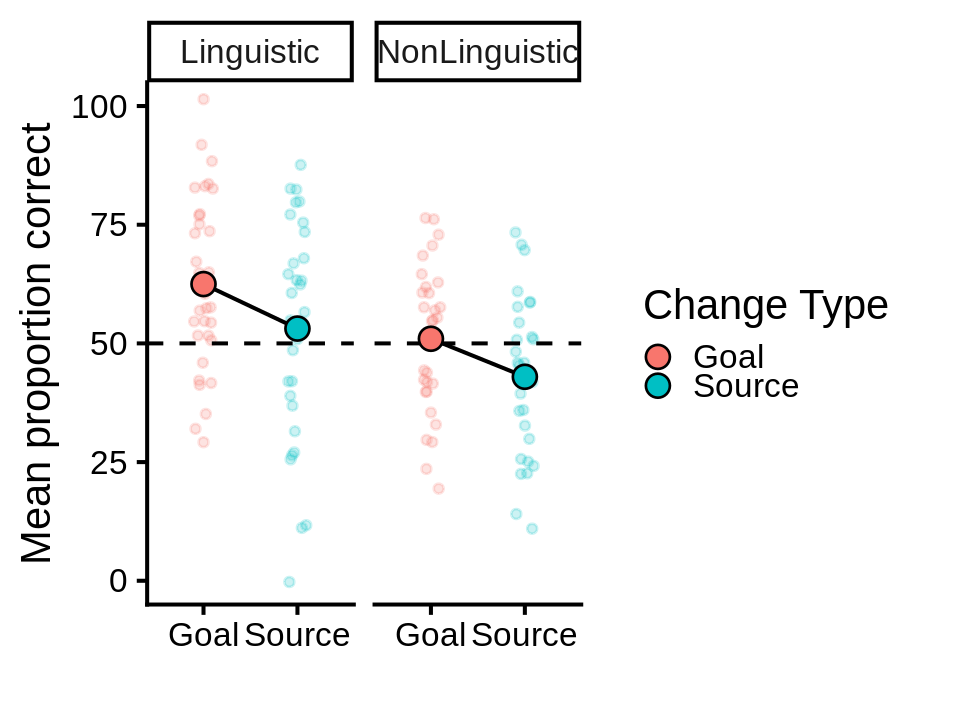

In [13]:
options(repr.plot.width = 8, repr.plot.height = 6)
accuracy_by_participant %>%
ggplot(aes(Change_type, accuracy*100)) +
geom_point(aes( color = Change_type), position = position_jitter(0.1), size = 2, alpha = 0.2)+
geom_hline(yintercept = 50, linetype = 2)+
stat_summary(fun="mean", geom="path", aes(group=1))+
facet_wrap(.~Encoding) +
stat_summary(aes(fill = Change_type), fun = "mean",  geom = "point", size = 6, shape = 21, color = "black")    +
coord_cartesian(ylim = c(0,100))+
labs(x="", y = "Mean proportion correct")+
guides(color=guide_legend(title="Change Type"))+
guides(fill=guide_legend(title="Change Type"))

In [14]:
memory_data <- memory_data %>% mutate(Encoding.fct = factor(Encoding)) %>% mutate(Change_type.fct = factor(Change_type))
contrasts(memory_data$Change_type.fct) = contr.sum(2)
contrasts(memory_data$Encoding.fct) = contr.sum(2)
m<- glmer(Correct ~ Change_type.fct * Encoding.fct + (1 |Participant) + (1 + Change_type.fct |Target_EventID ) , family = "binomial", data = memory_data)
summary(m)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Correct ~ Change_type.fct * Encoding.fct + (1 | Participant) +  
    (1 + Change_type.fct | Target_EventID)
   Data: memory_data

      AIC       BIC    logLik -2*log(L)  df.resid 
   2702.5    2747.5   -1343.2    2686.5      2040 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3222 -0.8774  0.4789  0.8426  2.1811 

Random effects:
 Groups         Name             Variance  Std.Dev. Corr
 Participant    (Intercept)      0.3829148 0.61880      
 Target_EventID (Intercept)      0.2079243 0.45599      
                Change_type.fct1 0.0001483 0.01218  1.00
Number of obs: 2048, groups:  Participant, 128; Target_EventID, 16

Fixed effects:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     0.11217    0.13512   0.830  0.40644    
Change_type.fct1                0.20127    0.07263   2.771  0.